## Telco Churn Predictor

## 1. Loading the dataset

In [47]:
from google.colab import drive

# Mounting google drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [48]:
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

In [49]:
# Importing the dataset
df_raw = pd.read_csv('/content/drive/MyDrive/Telco_Dataset.csv')

In [50]:
print("Dataset shape : ", df_raw.shape)

df_raw.head()

Dataset shape :  (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Understanding the dataset

### 2.1 Shape

In [51]:
print(f"Number of rows : {df_raw.shape[0]}")
print(f"Number of columns : {df_raw.shape[1]}")

Number of rows : 7043
Number of columns : 21


### 2.2 Columns

In [52]:
print("Column Names :")
print(df_raw.columns.tolist())

Column Names :
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


### 2.3 Datatypes

In [53]:
print("Datatypes :")
print(df_raw.dtypes)

Datatypes :
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


### 2.4 Number of unique values in each column

In [54]:
print("Number of unique values :")
print(df_raw.nunique())

Number of unique values :
customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64


### 2.5 Missing Values in each column

In [55]:
print("Missing Values :")
print(df_raw.isnull().sum())

Missing Values :
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


### 2.6 Duplicate rows

In [56]:
dup_rows = df_raw.duplicated().sum()
print(f"Number of duplicate rows : {dup_rows}")

Number of duplicate rows : 0


### 2.7 Statistical Summary

In [57]:
print("Statistical Summary :")
df_raw.describe()

Statistical Summary :


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 3. Exploratory Data Analysis

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
df_eda = df_raw.copy()

### 3.1 Churn Distribution

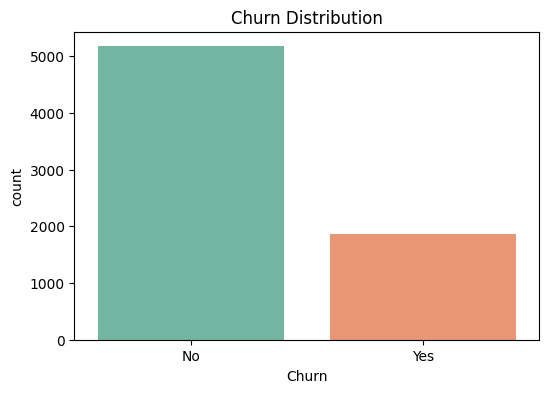

In [60]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df_eda, palette="Set2")
plt.title("Churn Distribution")
plt.show()

### 3.2 Distribution of Tenure

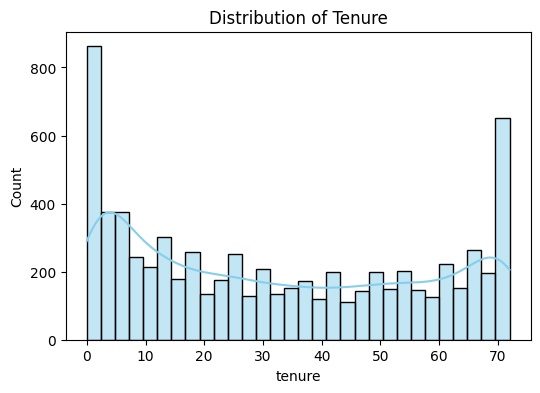

In [61]:
plt.figure(figsize=(6,4))
sns.histplot(df_eda["tenure"], bins=30, kde=True, color="skyblue")
plt.title("Distribution of Tenure")
plt.show()

### 3.3 Distribution of Monthly Charges

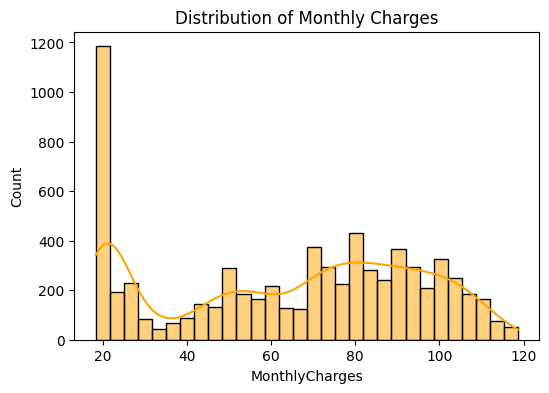

In [62]:
plt.figure(figsize=(6,4))
sns.histplot(df_eda["MonthlyCharges"], bins=30, kde=True, color="orange")
plt.title("Distribution of Monthly Charges")
plt.show()

### 3.4 Distribution of Total Charges

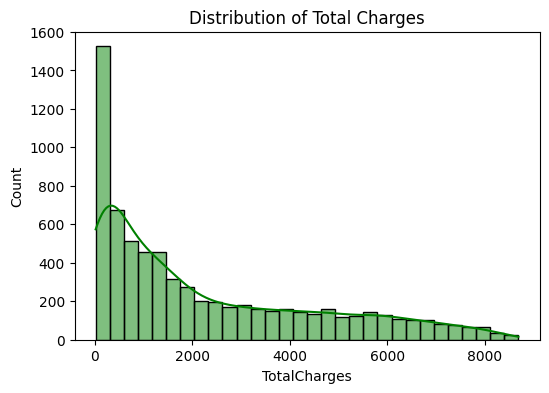

In [63]:
df_eda["TotalCharges"] = pd.to_numeric(df_eda["TotalCharges"], errors="coerce")
df_eda = df_eda.dropna()

plt.figure(figsize=(6,4))
sns.histplot(df_eda["TotalCharges"], bins=30, kde=True, color="green")
plt.title("Distribution of Total Charges")
plt.show()


### 3.5 Churn by Payment Method

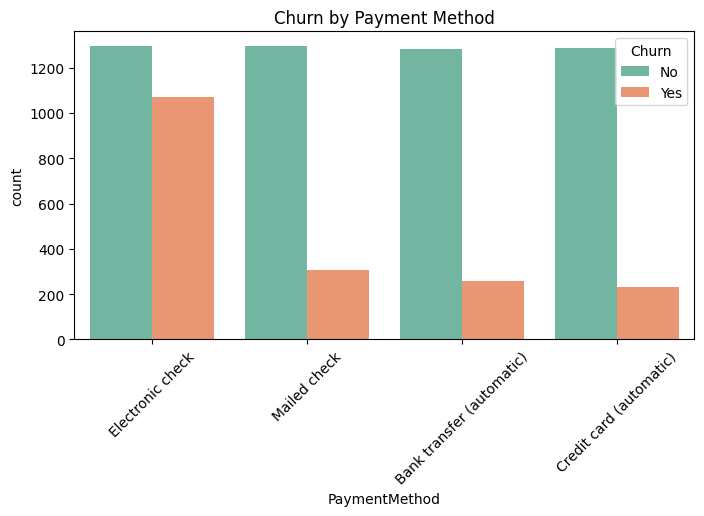

In [64]:
plt.figure(figsize=(8,4))
sns.countplot(x="PaymentMethod", hue="Churn", data=df_eda, palette="Set2")
plt.title("Churn by Payment Method")
plt.xticks(rotation=45)
plt.show()

### 3.6 Churn by Internet Service

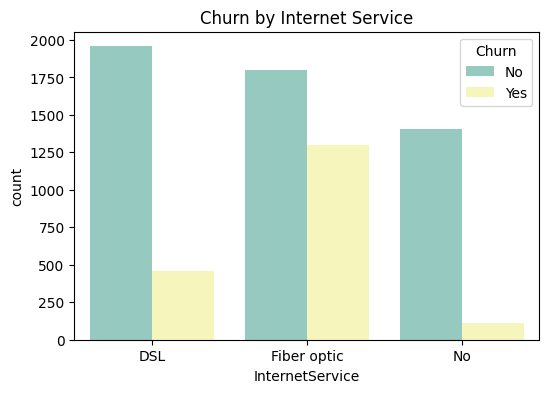

In [65]:
plt.figure(figsize=(6,4))
sns.countplot(x="InternetService", hue="Churn", data=df_eda, palette="Set3")
plt.title("Churn by Internet Service")
plt.show()

### 3.7 Correlation Heatmap (Numeric Features)

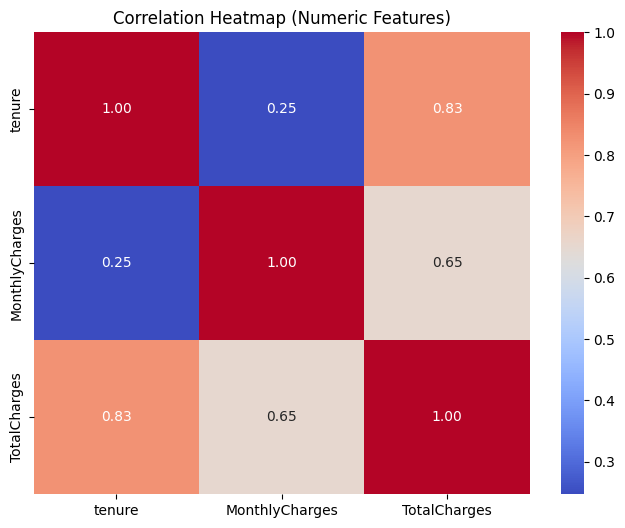

In [66]:
plt.figure(figsize=(8,6))
sns.heatmap(df_eda[["tenure","MonthlyCharges","TotalCharges"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

## 4. Preprocessing

We will be using df_copy for modelling purposes and df_raw will remain unchanged.

In [67]:
df_copy = df_raw.copy()

Changing TotalCharges from Object to Numeric dtype.

In [68]:
df_copy['TotalCharges'] = pd.to_numeric(df_copy['TotalCharges'], errors='coerce')

print(f"Number of NaN in TotalCharges column now : {df_copy['TotalCharges'].isnull().sum()}")

Number of NaN in TotalCharges column now : 11


In [69]:
df_copy = df_copy.dropna()

print(f"Number of NaN in TotalCharges column after dropping those rows : {df_copy['TotalCharges'].isnull().sum()}")

Number of NaN in TotalCharges column after dropping those rows : 0


In [70]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Seperate feature and target variables
X = df_copy.drop(columns=['Churn', 'customerID'])
y = df_copy['Churn']

# Seperating categorical and numerical columns
cat_columns = X.select_dtypes(include=['object', 'category']).columns
num_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Applying label encoders to categorical columns.
le = LabelEncoder()
for col in cat_columns:
    X[col] = le.fit_transform(X[col].astype(str))

# Scaling numerical columns. 
scaler = StandardScaler()
X[num_columns] = scaler.fit_transform(X[num_columns])

X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,-1.280248,0,1,0,0,2,0,0,0,0,0,1,2,-1.161694,-0.994194
1,1,0,0,0,0.064303,1,0,0,2,0,2,0,0,0,1,0,3,-0.260878,-0.173740
2,1,0,0,0,-1.239504,1,0,0,2,2,0,0,0,0,0,1,3,-0.363923,-0.959649
3,1,0,0,0,0.512486,0,1,0,2,0,2,2,0,0,1,0,0,-0.747850,-0.195248
4,0,0,0,0,-1.239504,1,0,1,0,0,0,0,0,0,0,1,2,0.196178,-0.940457


In [71]:
# Encoding target variable
churn_map = {
    "Yes" : 1,
    "No" : 0
}

y = df_copy['Churn'].map(churn_map)

y.head()

,Churn
0,0
1,0
2,1
3,0
4,1


Combining encoded feature and target variable to create df_model dataset to be used for modelling.

In [72]:
df_model = X.copy()
df_model['Churn'] = y

df_model.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,-1.280248,0,1,0,0,2,0,0,0,0,0,1,2,-1.161694,-0.994194,0
1,1,0,0,0,0.064303,1,0,0,2,0,2,0,0,0,1,0,3,-0.260878,-0.173740,0
2,1,0,0,0,-1.239504,1,0,0,2,2,0,0,0,0,0,1,3,-0.363923,-0.959649,1
3,1,0,0,0,0.512486,0,1,0,2,0,2,2,0,0,1,0,0,-0.747850,-0.195248,0
4,0,0,0,0,-1.239504,1,0,1,0,0,0,0,0,0,0,1,2,0.196178,-0.940457,1


## 5. Feature Selection

### 5.1 Checking for class imbalance

In [73]:
print(df_model['Churn'].value_counts())

print("\nClass proportions (%):")
print((df_model["Churn"].value_counts(normalize=True) * 100).round(2))

Churn
0    5163
1    1869
Name: count, dtype: int64

Class proportions (%):
Churn
0    73.42
1    26.58
Name: proportion, dtype: float64


### 5.2 Train-test-split data 

In [74]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Before SMOTE : ", y_train.value_counts().to_dict())

# Using smote because of class imbalance
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE : ", pd.Series(y_train_res).value_counts().to_dict())

Before SMOTE :  {0: 4130, 1: 1495}
After SMOTE :  {0: 4130, 1: 4130}


## 6. Model 

### 6.1 Creating and Comparing baseline performance

In [75]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "XGBoost" : XGBClassifier(random_state=42, eval_metric="mlogloss",
            use_label_encoder=False, n_jobs=-1)
}

In [76]:
import pandas as pd
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

results = []

for name, model in models.items():
    # Raw
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Data": "Raw",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "F1 Macro": f1_score(y_test, y_pred, average="macro"),
        "F1 Weighted": f1_score(y_test, y_pred, average="weighted")
    })

    # SMOTE
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Data": "SMOTE",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "F1 Macro": f1_score(y_test, y_pred, average="macro"),
        "F1 Weighted": f1_score(y_test, y_pred, average="weighted")
    })

# Convert to DataFrame
results_df = pd.DataFrame(results).sort_values(["Model", "Data"]).reset_index(drop=True)
results_df

,Model,Data,Accuracy,Balanced Accuracy,F1 Macro,F1 Weighted
0,Decision Tree,Raw,0.710732,0.644367,0.639905,0.714705
1,Decision Tree,SMOTE,0.708600,0.673618,0.656267,0.719086
2,KNN,Raw,0.761194,0.691526,0.692504,0.760574
3,KNN,SMOTE,0.722814,0.728501,0.689154,0.737064
4,Logistic Regression,Raw,0.793177,0.719277,0.726172,0.789615
5,Logistic Regression,SMOTE,0.721393,0.730091,0.688854,0.735982
6,Random Forest,Raw,0.781095,0.684610,0.697074,0.771797
7,Random Forest,SMOTE,0.757640,0.718103,0.705505,0.763541
8,XGBoost,Raw,0.773276,0.694637,0.700381,0.769600
9,XGBoost,SMOTE,0.754087,0.723359,0.706005,0.761692


### 6.2 Creating Ensemble Stack

In [77]:
# Random Forest (SMOTE)
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_res, y_train_res)

# XGBoost (SMOTE)
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_res, y_train_res)

# Logistic Regression (Raw, trained on original data)
log_reg_model = LogisticRegression(max_iter=1000)
log_reg_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [78]:
from sklearn.ensemble import StackingClassifier

estimators = [
    ('rf', rf_model),
    ('xgb', xgb_model)
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    passthrough=False
)
stack_model.fit(X_train_res, y_train_res)

StackingClassifier(estimators=[('rf', RandomForestClassifier(random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=True,
                                              eval_metric='logloss',
                                              feature_types=None,
                                              feature_weights=None, gamma=None,
                                              grow...
                                              importance_type=None,
                                              interaction_constraints=None,
                                              learning_rate=None, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=None,
                                              num_parallel_tree=None, ...))],
                   final_estimator=LogisticRegression(max_iter=1000))

### 6.3 Comparing baseline model and ensemle stack model

In [79]:
from sklearn.metrics import roc_auc_score

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]  # probability for positive class
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "F1 Macro": f1_score(y_test, y_pred, average='macro'),
        "F1 Weighted": f1_score(y_test, y_pred, average='weighted'),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }

results = []
results.append(evaluate_model("Logistic Regression (Raw)", log_reg_model, X_test, y_test))
results.append(evaluate_model("Random Forest (SMOTE)", rf_model, X_test, y_test))
results.append(evaluate_model("XGBoost (SMOTE)", xgb_model, X_test, y_test))
results.append(evaluate_model("Stacked Model (RF+XGB)", stack_model, X_test, y_test))

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Balanced Accuracy,F1 Macro,F1 Weighted,ROC-AUC
0,Logistic Regression (Raw),0.793177,0.719277,0.726172,0.789615,0.834536
1,Random Forest (SMOTE),0.757640,0.718103,0.705505,0.763541,0.806665
2,XGBoost (SMOTE),0.754087,0.723359,0.706005,0.761692,0.809745
3,Stacked Model (RF+XGB),0.761194,0.716259,0.706584,0.765872,0.811638


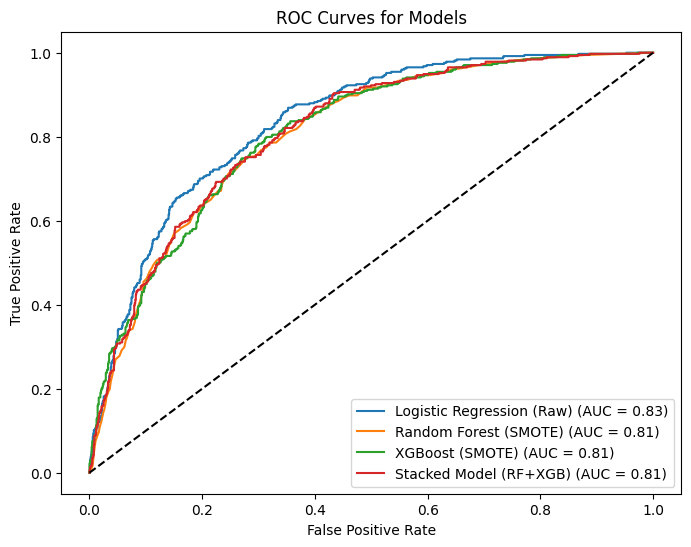

In [80]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

models = {
    "Logistic Regression (Raw)": log_reg_model,
    "Random Forest (SMOTE)": rf_model,
    "XGBoost (SMOTE)": xgb_model,
    "Stacked Model (RF+XGB)": stack_model
}

plt.figure(figsize=(8,6))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Models")
plt.legend(loc="lower right")
plt.show()


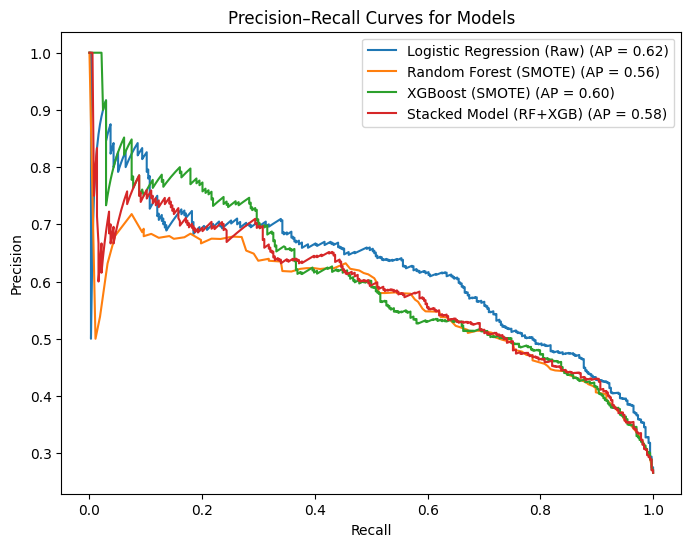

In [81]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

models = {
    "Logistic Regression (Raw)": log_reg_model,
    "Random Forest (SMOTE)": rf_model,
    "XGBoost (SMOTE)": xgb_model,
    "Stacked Model (RF+XGB)": stack_model
}

plt.figure(figsize=(8,6))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:,1]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    avg_precision = average_precision_score(y_test, y_proba)
    plt.plot(recall, precision, label=f"{name} (AP = {avg_precision:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves for Models")
plt.legend(loc="upper right")
plt.show()


### 6.4 Analysing Best Model (i.e. Logistic Regression Model (raw))

In [82]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Get predicted probabilities for the positive class (churn)
y_proba = log_reg_model.predict_proba(X_test)[:,1]

# Adjust threshold (default is 0.5, now set to 0.4)
threshold = 0.4
y_pred_thresh = np.where(y_proba >= threshold, 1, 0)

# Evaluate performance
print("Classification Report (Threshold=0.4):\n", classification_report(y_test, y_pred_thresh))
print("Confusion Matrix (Threshold=0.4):\n", confusion_matrix(y_test, y_pred_thresh))


Classification Report (Threshold=0.4):
               precision    recall  f1-score   support

           0       0.88      0.81      0.84      1033
           1       0.57      0.69      0.62       374

    accuracy                           0.78      1407
   macro avg       0.72      0.75      0.73      1407
weighted avg       0.79      0.78      0.78      1407

Confusion Matrix (Threshold=0.4):
 [[837 196]
 [117 257]]


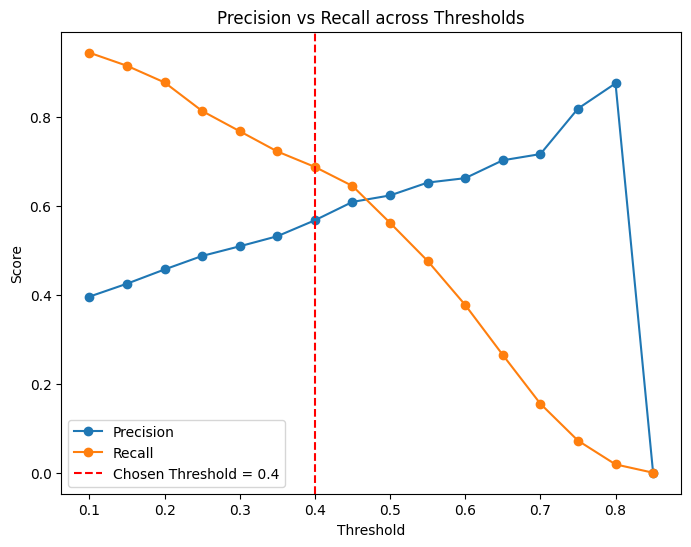

In [83]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score

# Probabilities from Logistic Regression
y_proba = log_reg_model.predict_proba(X_test)[:,1]

# Range of thresholds
thresholds = np.arange(0.1, 0.9, 0.05)

precisions = []
recalls = []

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred))
    recalls.append(recall_score(y_test, y_pred))

# Plot
plt.figure(figsize=(8,6))
plt.plot(thresholds, precisions, label="Precision", marker='o')
plt.plot(thresholds, recalls, label="Recall", marker='o')
plt.axvline(0.4, color='red', linestyle='--', label="Chosen Threshold = 0.4")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall across Thresholds")
plt.legend()
plt.show()


### 6.5 Hyperparameter tuning

In [84]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define parameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

# Grid search
grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='roc_auc'
)

grid.fit(X_train_res, y_train_res)

print("Best Parameters:", grid.best_params_)
print("Best ROC-AUC:", grid.best_score_)

tuned_log_reg = grid.best_estimator_

Best Parameters: {'C': 1, 'penalty': 'l1', 'solver': 'saga'}
Best ROC-AUC: 0.8683015377940893


In [85]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score
import pandas as pd

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "F1 Macro": f1_score(y_test, y_pred, average='macro'),
        "F1 Weighted": f1_score(y_test, y_pred, average='weighted'),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }

# Evaluate default vs tuned Logistic Regression
results = []
results.append(evaluate_model("Logistic Regression (Default)", log_reg_model, X_test, y_test))
results.append(evaluate_model("Logistic Regression (Tuned)", tuned_log_reg, X_test, y_test))

df = pd.DataFrame(results)
print(df)

                           Model  Accuracy  Balanced Accuracy  F1 Macro  \
0  Logistic Regression (Default)  0.793177           0.719277  0.726172   
1    Logistic Regression (Tuned)  0.720682           0.729607  0.688221   

   F1 Weighted   ROC-AUC  
0     0.789615  0.834536  
1     0.735340  0.818885  


### 6.6 Cross Validating 

In [86]:
from sklearn.model_selection import cross_val_score

# Evaluate Logistic Regression with CV
cv_scores = cross_val_score(log_reg_model, X_train, y_train, 
                            cv=5, scoring='roc_auc')

print("CV ROC-AUC scores:", cv_scores)
print("Mean ROC-AUC:", cv_scores.mean())
print("Std Dev:", cv_scores.std())

CV ROC-AUC scores: [0.83421534 0.87207965 0.84384186 0.81866512 0.85735745]
Mean ROC-AUC: 0.8452318867573103
Std Dev: 0.018422384603684616


### 6.7 SHAP Analysis

In [87]:
import shap
import pandas as pd

# SHAP for Logistic Regression
explainer = shap.LinearExplainer(log_reg_model, X_train_res)
shap_values = explainer.shap_values(X_test)

# Mean absolute SHAP values for feature importance
importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": np.abs(shap_values).mean(axis=0)
}).sort_values(by="Importance", ascending=False)

print(importance.head(10))


             Feature  Importance
4             tenure    1.190898
17    MonthlyCharges    0.588322
14          Contract    0.537879
18      TotalCharges    0.488877
8     OnlineSecurity    0.228559
11       TechSupport    0.209885
5       PhoneService    0.173346
15  PaperlessBilling    0.151716
7    InternetService    0.125498
9       OnlineBackup    0.124302


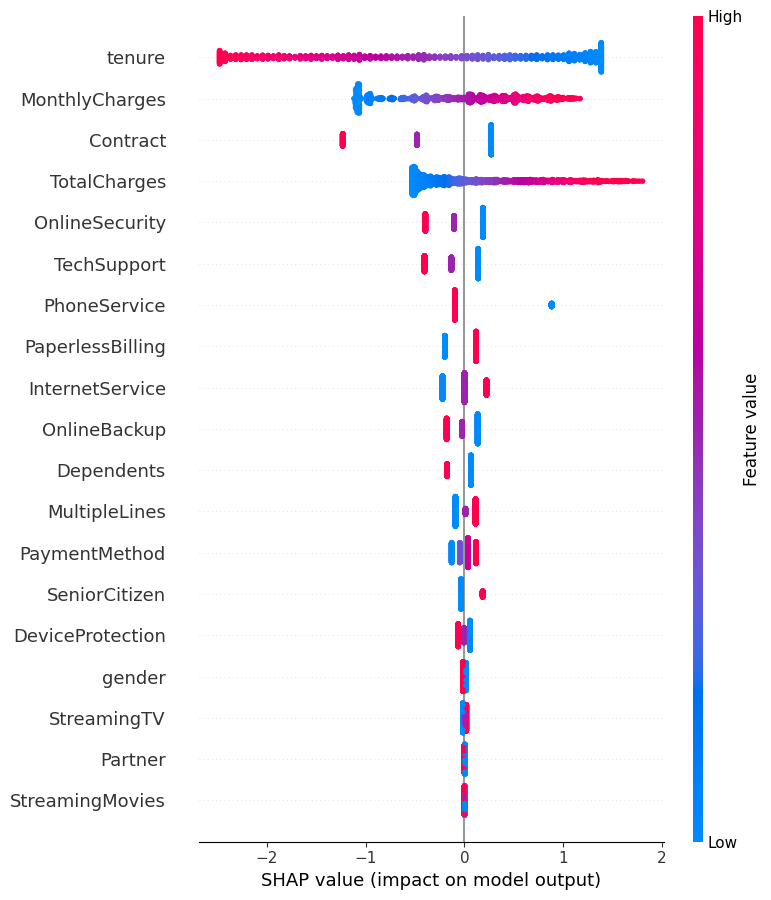

In [88]:
shap.summary_plot(shap_values, X_test)

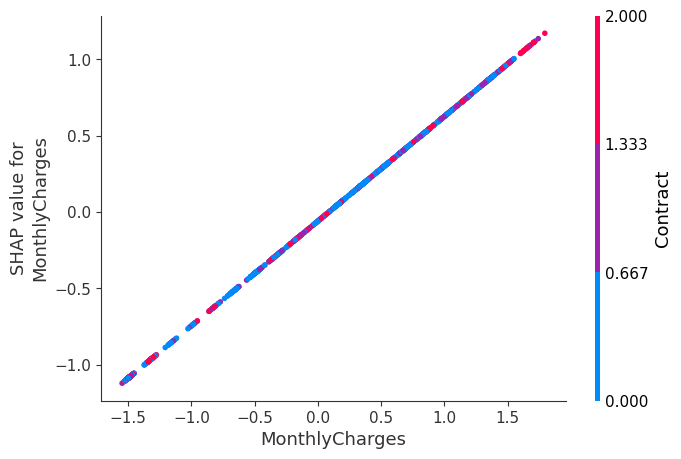

In [89]:
shap.dependence_plot("MonthlyCharges", shap_values, X_test)

## 7. Final Model Deployment

### 7.1 Creating Pipeline

In [90]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [91]:
preprocessor = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_columns),
        ('num', StandardScaler(), num_columns)
    ]
)

In [92]:
# Full pipeline: preprocessing + logistic regression
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('logreg', log_reg_model)   # logistic regression
])

# Fit pipeline
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')),
                                                 ('num', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges'])])),
                ('logreg', LogisticRegression(max_iter=1000))])

In [93]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:,1]

print("="*70)
print("FINAL DEPLOYMENT MODEL")
print("="*70)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}")

print(f"Macro F1: {f1_score(y_test, y_pred, average='macro'):.4f}")

print(f"F1 Weighted: {f1_score(y_test, y_pred, average='weighted'):.4f}")

print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

print("\nClassification Report")
print("="*70)

print(classification_report(y_test, y_pred))

FINAL DEPLOYMENT MODEL
Accuracy: 0.7996
Balanced Accuracy: 0.7245
Macro F1: 0.7329
F1 Weighted: 0.7954
ROC-AUC: 0.8347

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1033
           1       0.64      0.56      0.60       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.80      1407



### 7.2 Testing Pipeline

In [94]:
import pandas as pd

# Full test data with all columns
test_data = pd.DataFrame([
    {
        "customerID": "0001-A",
        "gender": "Female",
        "SeniorCitizen": 0,
        "Partner": "Yes",
        "Dependents": "No",
        "tenure": 5,
        "PhoneService": "Yes",
        "MultipleLines": "No",
        "InternetService": "DSL",
        "OnlineSecurity": "No",
        "OnlineBackup": "Yes",
        "DeviceProtection": "No",
        "TechSupport": "No",
        "StreamingTV": "Yes",
        "StreamingMovies": "No",
        "Contract": "Month-to-month",
        "PaperlessBilling": "Yes",
        "PaymentMethod": "Electronic check",
        "MonthlyCharges": 70.35,
        "TotalCharges": 351.75,
        "Churn": "Yes"
    },
    {
        "customerID": "0002-B",
        "gender": "Male",
        "SeniorCitizen": 1,
        "Partner": "No",
        "Dependents": "No",
        "tenure": 24,
        "PhoneService": "Yes",
        "MultipleLines": "Yes",
        "InternetService": "Fiber optic",
        "OnlineSecurity": "No",
        "OnlineBackup": "No",
        "DeviceProtection": "Yes",
        "TechSupport": "No",
        "StreamingTV": "Yes",
        "StreamingMovies": "Yes",
        "Contract": "One year",
        "PaperlessBilling": "No",
        "PaymentMethod": "Credit card",
        "MonthlyCharges": 95.50,
        "TotalCharges": 2292.00,
        "Churn": "No"
    },
    {
        "customerID": "0003-C",
        "gender": "Female",
        "SeniorCitizen": 0,
        "Partner": "Yes",
        "Dependents": "Yes",
        "tenure": 60,
        "PhoneService": "No",
        "MultipleLines": "No phone service",
        "InternetService": "DSL",
        "OnlineSecurity": "Yes",
        "OnlineBackup": "Yes",
        "DeviceProtection": "Yes",
        "TechSupport": "Yes",
        "StreamingTV": "No",
        "StreamingMovies": "No",
        "Contract": "Two year",
        "PaperlessBilling": "No",
        "PaymentMethod": "Mailed check",
        "MonthlyCharges": 55.00,
        "TotalCharges": 3300.00,
        "Churn": "No"
    }
])

print(test_data.head())


  customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0     0001-A  Female              0     Yes         No       5          Yes   
1     0002-B    Male              1      No         No      24          Yes   
2     0003-C  Female              0     Yes        Yes      60           No   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0                No             DSL             No  ...               No   
1               Yes     Fiber optic             No  ...              Yes   
2  No phone service             DSL            Yes  ...              Yes   

  TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling  \
0          No         Yes              No  Month-to-month              Yes   
1          No         Yes             Yes        One year               No   
2         Yes          No              No        Two year               No   

      PaymentMethod MonthlyCharges  TotalCharges  Churn  
0  Elec

In [95]:
# Drop target + ID for prediction
X_test_sample = test_data.drop(columns=["Churn", "customerID"])
y_test_sample = test_data["Churn"].map({"No":0, "Yes":1})

# Predict
y_pred = pipeline.predict(X_test_sample)
y_proba = pipeline.predict_proba(X_test_sample)[:,1]

print("Predictions:", y_pred)
print("Probabilities:", y_proba)

Predictions: [1 1 1]
Probabilities: [1. 1. 1.]


### 7.3 Deploying Pipeline

In [96]:
import joblib
joblib.dump(pipeline, "log_reg_pipeline.pkl")

['log_reg_pipeline.pkl']